# Part 1 — Data Integration for Southwark

**Research Question:** How can property-level EPC, house price and accessibility data be integrated into a multidimensional Housing Equity Index for Southwark?

**Pipeline:**
1. EPC aggregation (property-level → LSOA)
2. House price aggregation (LSOA time series → single cross-section)
3. Transport & healthcare variables merge
4. Master dataset assembly → `master_southwark.csv`

## 0. Setup

In [61]:
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data')

PATHS = {
    'epc'        : os.path.join(DATA_DIR, 'epc_london_building_stock.csv'),
    'house_price': os.path.join(DATA_DIR, 'land_registry_house_prices_LSOA.csv'),
    'transport'  : os.path.join(DATA_DIR, 'transport_accessibility_LSOA2011.csv'),
    'healthcare' : os.path.join(DATA_DIR, 'healthcare_accessibility_LSOA.csv'),
}
FIG_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
print('Paths configured. FIG_DIR:', FIG_DIR)

Paths configured. FIG_DIR: /Users/kevin/Desktop/代写/lxy/code/figures


---
## 1. EPC Aggregation
**Source:** `epc_london_building_stock.csv` (property-level, ~2.2 GB)  
**Output:** LSOA-level EPC metrics + overcrowding index

In [62]:
# --- 1.1  Load selected columns only (memory-efficient) ---
epc_cols = [
    'uprn',
    'lsoa11cd', 'lsoa21cd', 'lsoa21nm',
    'epc_rating', 'epc_score',
    'total_floor_area', 'number_habitable_rooms',
    'tenure', 'property_type', 'construction_age_band'
]

epc_raw = pd.read_csv(PATHS['epc'], usecols=epc_cols, low_memory=False)
print(f'Full London EPC: {epc_raw.shape[0]:,} properties')

Full London EPC: 3,887,534 properties


In [63]:
# --- 1.2  Filter Southwark ---
epc_swk = epc_raw[epc_raw['lsoa21nm'].str.contains('Southwark', na=False)].copy()
print(f'Southwark properties : {len(epc_swk):,}')
print(f'Southwark LSOAs      : {epc_swk["lsoa21cd"].nunique()}')
epc_swk.head(3)

Southwark properties : 149,054
Southwark LSOAs      : 173


,uprn,lsoa21cd,lsoa21nm,lsoa11cd,property_type,tenure,construction_age_band,epc_score,epc_rating,number_habitable_rooms,total_floor_area
2664425,10094746647,E01003914,Southwark 024B,E01003914,flat,owner-occupied,1900-1929,77,C,3,51
2664426,200003467424,E01003914,Southwark 024B,E01003914,flat,social,pre-1900,70,C,up to 2,61
2664427,10009795475,E01003914,Southwark 024B,E01003914,flat,private-rented,1900-1929,69,C,3,59


In [64]:
# --- 1.3  Force numeric types & EPC rating → numeric score (A=7 … G=1) ---
# epc_score / total_floor_area / number_habitable_rooms may be read as object dtype
for col in ['epc_score', 'total_floor_area', 'number_habitable_rooms']:
    epc_swk[col] = pd.to_numeric(epc_swk[col], errors='coerce')

# Higher number = more energy-efficient = better housing quality
rating_map = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
epc_swk['epc_rating_num'] = epc_swk['epc_rating'].str.upper().map(rating_map)

# Distribution check
print('EPC rating distribution:')
print(epc_swk['epc_rating'].value_counts().sort_index())
print('\ndtypes after conversion:')
print(epc_swk[['epc_score','total_floor_area','number_habitable_rooms']].dtypes)

EPC rating distribution:
epc_rating
A-B    23821
C      68361
D      46726
E       8982
F-G     1164
Name: count, dtype: int64

dtypes after conversion:
epc_score                   int64
total_floor_area            int64
number_habitable_rooms    float64
dtype: object


In [65]:
# --- 1.4  Aggregate to LSOA level ---
epc_lsoa = (
    epc_swk
    .groupby(['lsoa11cd', 'lsoa21cd', 'lsoa21nm'], as_index=False)
    .agg(
        n_properties       = ('uprn',             'count'),
        avg_epc_score      = ('epc_score',         'mean'),   # raw SAP score (0–100)
        avg_epc_rating_num = ('epc_rating_num',    'mean'),   # numeric band avg
        pct_epc_ABC        = ('epc_rating',        lambda x: x.isin(['A','B','C']).mean() * 100),
        avg_floor_area     = ('total_floor_area',  'mean'),   # m²
        avg_rooms          = ('number_habitable_rooms', 'mean'),
    )
)

# --- 1.5  Overcrowding index ---
# Formula: 1 / (avg_floor_area × avg_rooms)
# Larger value = smaller and fewer rooms = more overcrowded
epc_lsoa['overcrowding_idx'] = 1 / (
    epc_lsoa['avg_floor_area'] * epc_lsoa['avg_rooms']
)

print(f'EPC LSOA table: {epc_lsoa.shape}')
epc_lsoa.describe().T

EPC LSOA table: (177, 10)


,count,mean,std,min,25%,50%,75%,max
n_properties,177.0000,842.1130,228.8810,1.0000,700.0000,814.0000,954.0000,1741.0000
avg_epc_score,177.0000,69.7444,4.6613,52.0909,66.6503,69.8828,73.0600,85.2709
avg_epc_rating_num,177.0000,4.4782,0.2257,3.5455,4.3256,4.5183,4.6348,5.0000
pct_epc_ABC,177.0000,45.9126,15.4091,0.0000,36.5714,46.1272,57.0152,100.0000
avg_floor_area,177.0000,76.3402,17.9635,45.8182,66.0384,72.0049,80.6971,178.9981
avg_rooms,177.0000,3.6702,0.3581,3.0000,3.3865,3.6101,3.8860,4.7596
overcrowding_idx,177.0000,0.0038,0.0009,0.0012,0.0032,0.0038,0.0044,0.0073


In [66]:
# Quick sanity check — verify a few LSOAs look sensible
epc_lsoa[['lsoa21nm','n_properties','avg_epc_rating_num',
           'avg_floor_area','avg_rooms','overcrowding_idx']].sort_values(
    'overcrowding_idx', ascending=False).head(5)

,lsoa21nm,n_properties,avg_epc_rating_num,avg_floor_area,avg_rooms,overcrowding_idx
72,Southwark 023A,11,3.5455,45.8182,3.0000,0.0073
168,Southwark 009G,1741,4.6909,55.4854,3.1125,0.0058
13,Southwark 021E,1027,4.2753,57.2201,3.1072,0.0056
17,Southwark 002G,1056,4.7934,56.8532,3.1375,0.0056
121,Southwark 010B,924,4.5813,57.2944,3.2353,0.0054


---
## 2. House Price Aggregation
**Source:** `land_registry_house_prices_LSOA.csv` (LSOA × quarter time series, up to Dec 2017)  
**Output:** Most-recent-year median house price per Southwark LSOA

In [67]:
# --- 2.1  Load and filter Southwark ---
southwark_lsoa11 = set(epc_lsoa['lsoa11cd'].unique())

hp_raw = pd.read_csv(PATHS['house_price'], low_memory=False)
hp_swk = hp_raw[hp_raw['Code'].isin(southwark_lsoa11)].copy()
print(f'House price rows (Southwark): {len(hp_swk):,}')
print(f'Measures available          : {hp_swk["Measure"].unique()}')

House price rows (Southwark): 44,322
Measures available          : <StringArray>
['Median', 'Mean', 'Sales']
Length: 3, dtype: str


In [68]:
# --- 2.2  Extract year and filter Median + most recent year ---
hp_swk['year_num'] = hp_swk['Year'].str.extract(r'(\d{4})').astype(int)

# Keep median only
hp_median = hp_swk[hp_swk['Measure'] == 'Median'].copy()

latest_year = hp_median['year_num'].max()
print(f'Latest year available: {latest_year}')

hp_latest = (
    hp_median[hp_median['year_num'] == latest_year]
    [['Code', 'Value']]
    .rename(columns={'Code': 'lsoa11cd', 'Value': 'median_house_price'})
)

# Ensure numeric (mixed-type column warning)
hp_latest['median_house_price'] = pd.to_numeric(hp_latest['median_house_price'], errors='coerce')

print(f'Southwark LSOAs with price data: {len(hp_latest)}')
hp_latest.describe()

Latest year available: 2017
Southwark LSOAs with price data: 664


,median_house_price
count,609.0000
mean,542879.5369
std,218750.8041
min,236500.0000
25%,399000.0000
50%,495000.0000
75%,615000.0000
max,1710000.0000


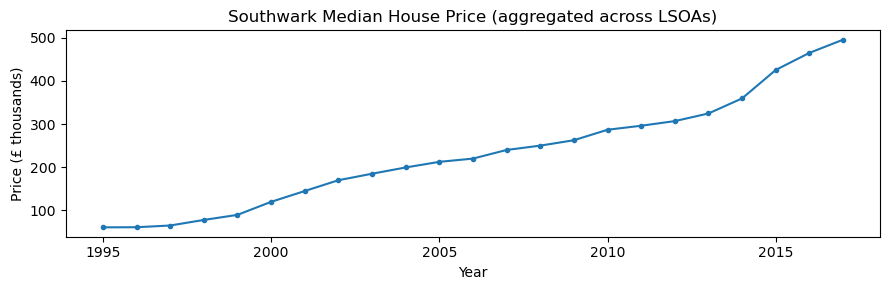

In [69]:
# --- 2.3  Price trend check (all years, Southwark aggregate) ---
import matplotlib.pyplot as plt

# hp_median still uses the original 'Value' column (rename only applies to hp_latest)
hp_trend = (
    hp_median.groupby('year_num')['Value']
    .apply(lambda x: pd.to_numeric(x, errors='coerce').median())
    .reset_index()
    .rename(columns={'Value': 'median_house_price'})
)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(hp_trend['year_num'], hp_trend['median_house_price'] / 1e3, marker='o', ms=3)
ax.set(title='Southwark Median House Price (aggregated across LSOAs)',
       xlabel='Year', ylabel='Price (£ thousands)')
plt.tight_layout()
plt.show()

---
## 3. Accessibility Variables

### 3.1 Transport Accessibility (PTAI 2015, LSOA 2011)

In [70]:
transport_raw = pd.read_csv(PATHS['transport'])

transport_swk = (
    transport_raw[transport_raw['LSOA2011'].isin(southwark_lsoa11)]
    .copy()
    .rename(columns={
        'LSOA2011'  : 'lsoa11cd',
        'AvPTAI2015': 'transport_ptai',
        'PTAL'      : 'ptal_grade',
        'PTAIHigh'  : 'ptai_high',
        'PTAILow'   : 'ptai_low',
    })
)

print(f'Transport rows (Southwark): {len(transport_swk)}')
print(f'PTAL grades: {sorted(transport_swk["ptal_grade"].unique())}')
transport_swk.describe()

Transport rows (Southwark): 166
PTAL grades: ['1b', '2', '3', '4', '5', '6a', '6b']


,transport_ptai,ptai_high,ptai_low
count,166.0000,166.0000,166.0000
mean,23.6165,34.7551,13.4248
std,22.0304,28.9651,16.5598
min,3.3337,5.4992,0.0000
25%,10.9444,17.2588,3.7760
50%,16.5735,23.8068,9.0408
75%,24.9072,38.7535,14.2475
max,121.8870,135.6690,110.6810


### 3.2 Healthcare Accessibility (AHAH dataset, LSOA 2021)

In [71]:
southwark_lsoa21 = set(epc_lsoa['lsoa21cd'].unique())

hc_raw = pd.read_csv(PATHS['healthcare'])

# Select variables relevant to HEI
hc_cols = [
    'lsoa21cd',
    'hospital',      # hospital accessibility score
    'GP',            # GP accessibility score
    'pharmacy',      # pharmacy accessibility score
    'hospital_rnk',  # national rank (lower = more accessible)
    'hospital_pct',  # national percentile
    'domain_h',      # AHAH health domain composite
    'ahah',          # overall AHAH index
]

healthcare_swk = (
    hc_raw[hc_raw['lsoa21cd'].isin(southwark_lsoa21)]
    [hc_cols]
    .copy()
)

print(f'Healthcare rows (Southwark): {len(healthcare_swk)}')
healthcare_swk.describe()

Healthcare rows (Southwark): 173


,hospital,GP,pharmacy,hospital_rnk,hospital_pct,domain_h,ahah
count,173.0000,173.0000,173.0000,173.0000,173.0000,173.0000,173.0000
mean,1.3584,1.4851,1.4160,13040.3988,29.8035,-0.5565,40.8685
std,0.5909,0.6030,0.5227,8390.3981,19.5188,0.4721,8.2561
min,0.5167,0.5222,0.5417,380.0000,0.0000,-2.0814,21.8624
25%,0.9367,1.0801,1.0464,6129.0000,14.0000,-0.8394,34.2333
50%,1.2611,1.3161,1.3214,12426.0000,28.0000,-0.5316,40.3943
75%,1.6963,1.7432,1.7268,19846.0000,46.0000,-0.2672,46.5261
max,3.5509,3.8325,3.7089,33252.0000,77.0000,0.4929,59.7330


---
## 4. Master Dataset Assembly

**Join key strategy:**
- `lsoa11cd` → EPC ↔ House Price ↔ Transport (all use LSOA 2011)
- `lsoa21cd` → EPC ↔ Healthcare (uses LSOA 2021)

In [72]:
# --- 4.1  Sequential left joins ---
master = epc_lsoa.copy()                                     # 166 Southwark LSOAs as base

master = master.merge(hp_latest,
                      on='lsoa11cd', how='left')             # house price

master = master.merge(transport_swk[['lsoa11cd','transport_ptai','ptal_grade',
                                      'ptai_high','ptai_low']],
                      on='lsoa11cd', how='left')             # transport

master = master.merge(healthcare_swk,
                      on='lsoa21cd', how='left')             # healthcare

print(f'Master shape: {master.shape}')
master.head(3)

Master shape: (708, 22)


,lsoa11cd,lsoa21cd,lsoa21nm,n_properties,avg_epc_score,avg_epc_rating_num,pct_epc_ABC,avg_floor_area,avg_rooms,overcrowding_idx,median_house_price,transport_ptai,ptal_grade,ptai_high,ptai_low,hospital,GP,pharmacy,hospital_rnk,hospital_pct,domain_h,ahah
0,E01003911,E01003911,Southwark 020A,821,67.3130,4.4168,44.8234,68.8161,3.4706,0.0042,425000.0000,14.2850,3,23.1377,8.5079,1.0262,1.4802,0.9914,7895,18,-0.9767,33.0962
1,E01003911,E01003911,Southwark 020A,821,67.3130,4.4168,44.8234,68.8161,3.4706,0.0042,465000.0000,14.2850,3,23.1377,8.5079,1.0262,1.4802,0.9914,7895,18,-0.9767,33.0962
2,E01003911,E01003911,Southwark 020A,821,67.3130,4.4168,44.8234,68.8161,3.4706,0.0042,484750.0000,14.2850,3,23.1377,8.5079,1.0262,1.4802,0.9914,7895,18,-0.9767,33.0962


In [73]:
# --- 4.2  Missing value audit ---
missing = master.isnull().sum()
missing_pct = (master.isnull().mean() * 100).round(2)

audit = pd.DataFrame({'missing_n': missing, 'missing_%': missing_pct})
audit = audit[audit['missing_n'] > 0]
print('Columns with missing values:')
print(audit.to_string())

Columns with missing values:
                    missing_n  missing_%
median_house_price         55     7.7700


In [74]:
# --- 4.3  Core HEI variable summary ---
hei_vars = [
    'avg_epc_rating_num',    # EPC quality
    'overcrowding_idx',      # Overcrowding
    'median_house_price',    # House price
    'transport_ptai',        # Transport accessibility
    'hospital',              # Healthcare accessibility
]

print('=== Core HEI Variables — Southwark LSOAs ===')
master[hei_vars].describe().T.round(3)

=== Core HEI Variables — Southwark LSOAs ===


,count,mean,std,min,25%,50%,75%,max
avg_epc_rating_num,708.0000,4.4780,0.2250,3.5450,4.3260,4.5180,4.6350,5.0000
overcrowding_idx,708.0000,0.0040,0.0010,0.0010,0.0030,0.0040,0.0040,0.0070
median_house_price,653.0000,541461.2760,221880.1560,236500.0000,395000.0000,500000.0000,601500.0000,1710000.0000
transport_ptai,708.0000,24.2960,22.3560,3.3340,10.9030,16.5960,25.3850,121.8870
hospital,708.0000,1.3580,0.5830,0.5170,0.9490,1.2660,1.6770,3.5510


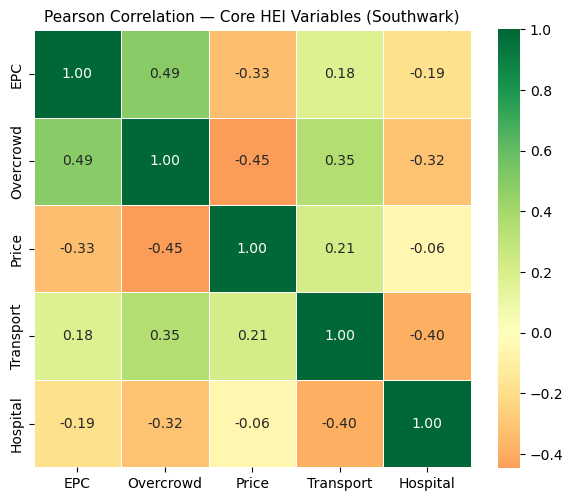

In [75]:
# --- 4.4  Pairwise correlation heatmap ---
import seaborn as sns
import matplotlib.pyplot as plt

corr = master[hei_vars].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=0.5,
    xticklabels=['EPC','Overcrowd','Price','Transport','Hospital'],
    yticklabels=['EPC','Overcrowd','Price','Transport','Hospital'],
    ax=ax
)
ax.set_title('Pearson Correlation — Core HEI Variables (Southwark)', fontsize=11)
plt.tight_layout()
plt.show()

In [76]:
# --- 4.5  Spatial distribution preview ---
import geopandas as gpd
import glob

SHP_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'LSOA_Shapfile')
shp_files = glob.glob(os.path.join(SHP_DIR, '*.shp'))

lsoa_gdf = gpd.read_file(shp_files[0]).to_crs(epsg=27700)

# Join master to geometry — try both 2011 and 2021 code columns
lsoa_col = [c for c in lsoa_gdf.columns if 'cd' in c.lower() or 'code' in c.lower()]
print('Geometry LSOA code columns:', lsoa_col)

# Filter Southwark geometry
geo_swk = lsoa_gdf[lsoa_gdf[lsoa_col[0]].isin(southwark_lsoa11 | southwark_lsoa21)].copy()
print(f'Southwark geometries: {len(geo_swk)}')

Geometry LSOA code columns: ['lsoa21cd', 'msoa21cd', 'lad22cd']
Southwark geometries: 173


  Shapefile: 173 polygons | master unique lsoa11cd: 166
  avg_epc_rating_num: 19 NaN → median 4.5148
  overcrowding_idx: 19 NaN → median 0.0038
  median_house_price: 28 NaN → median 481250.0000
  transport_ptai: 19 NaN → median 16.5735
  hospital: 19 NaN → median 1.3139


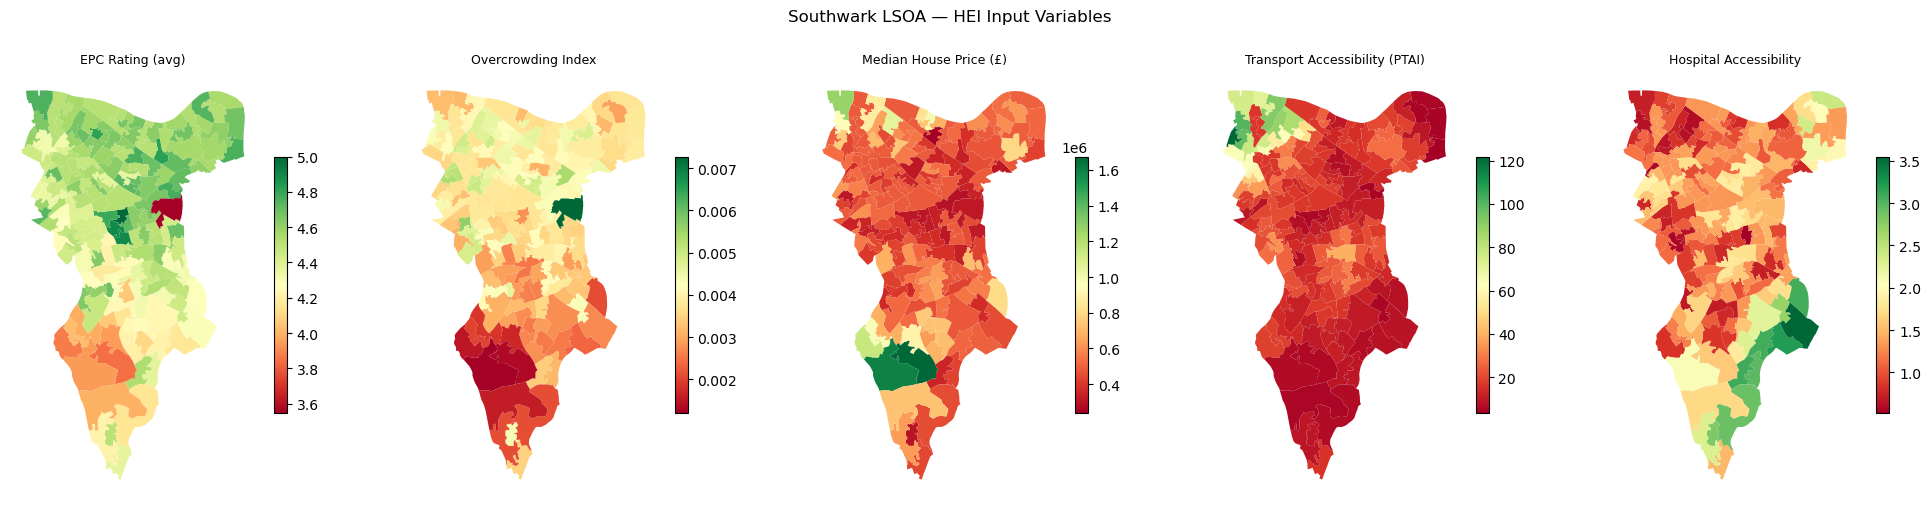

In [77]:
# Quick map of 5 HEI variables
geo_code_col = lsoa_col[0]
_plot_vars = ['avg_epc_rating_num', 'overcrowding_idx',
              'median_house_price', 'transport_ptai', 'hospital']

# Determine join key; deduplicate master on that key to avoid 1-to-many fan-out
_join_key = 'lsoa11cd' if geo_swk[geo_code_col].isin(master['lsoa11cd']).mean() > 0.5 else 'lsoa21cd'
_master_dedup = master[[_join_key] + _plot_vars].drop_duplicates(subset=[_join_key], keep='first')
print(f'  Shapefile: {len(geo_swk)} polygons | master unique {_join_key}: {_master_dedup[_join_key].nunique()}')

geo_master = geo_swk.merge(_master_dedup,
                           left_on=geo_code_col, right_on=_join_key, how='left')

# Fill NaN in plot vars (unmatched polygons or missing join records)
for _col in _plot_vars:
    _n = geo_master[_col].isnull().sum()
    if _n:
        _med = geo_master[_col].median()
        geo_master[_col] = geo_master[_col].fillna(_med)
        print(f'  {_col}: {_n} NaN → median {_med:.4f}')

plot_vars = {
    'avg_epc_rating_num' : 'EPC Rating (avg)',
    'overcrowding_idx'   : 'Overcrowding Index',
    'median_house_price' : 'Median House Price (£)',
    'transport_ptai'     : 'Transport Accessibility (PTAI)',
    'hospital'           : 'Hospital Accessibility',
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, (col, title) in zip(axes, plot_vars.items()):
    geo_master.plot(column=col, cmap='RdYlGn', legend=True,
                    legend_kwds={'shrink': 0.6}, ax=ax, missing_kwds={'color':'lightgrey'})
    ax.set_title(title, fontsize=9)
    ax.axis('off')

fig.suptitle('Southwark LSOA — HEI Input Variables', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Save Master Dataset

---
## 6. Overcrowding Proxy — Finalisation

`overcrowding_idx` was computed in Section 1.5 as `1 / (avg_floor_area × avg_rooms)`.  
Here we check the distribution and decide whether a log-transform is needed before normalisation.

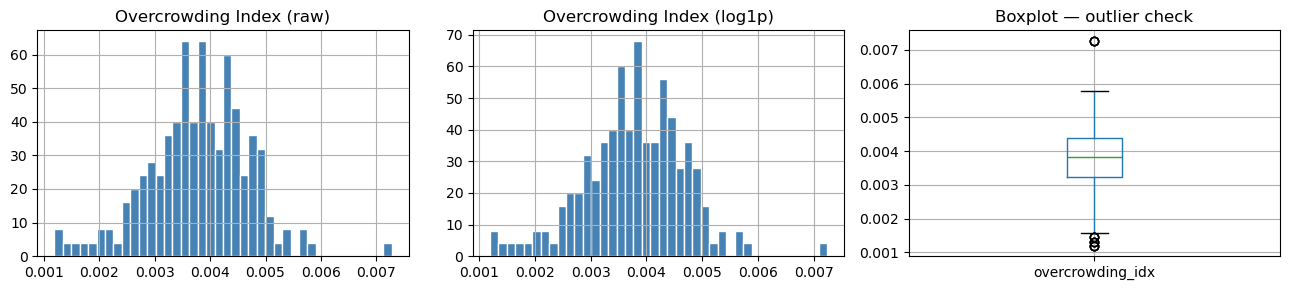

count   708.0000
mean      0.0038
std       0.0009
min       0.0012
25%       0.0032
50%       0.0038
75%       0.0044
max       0.0073
Name: overcrowding_idx, dtype: float64

Skewness (raw): -0.13
Skewness (log1p): -0.13

→ Use log1p transform if |skewness| > 1


In [78]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

master['overcrowding_idx'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Overcrowding Index (raw)')

np.log1p(master['overcrowding_idx']).hist(bins=40, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Overcrowding Index (log1p)')

master.boxplot(column='overcrowding_idx', ax=axes[2])
axes[2].set_title('Boxplot — outlier check')

plt.tight_layout()
plt.show()

print(master['overcrowding_idx'].describe().round(6))
skew = master['overcrowding_idx'].skew()
print(f'\nSkewness (raw): {skew:.2f}')
print(f'Skewness (log1p): {np.log1p(master["overcrowding_idx"]).skew():.2f}')
print('\n→ Use log1p transform if |skewness| > 1')

In [79]:
# Apply log1p if skewed, otherwise keep raw
if master['overcrowding_idx'].skew() > 1:
    master['overcrowding_proxy'] = np.log1p(master['overcrowding_idx'])
    print('Log1p transform applied → overcrowding_proxy = log1p(overcrowding_idx)')
else:
    master['overcrowding_proxy'] = master['overcrowding_idx']
    print('No transform needed → overcrowding_proxy = overcrowding_idx')

# ── Sanitise overcrowding_proxy: replace inf/-inf → NaN, then median-fill ──
master['overcrowding_proxy'] = master['overcrowding_proxy'].replace(
    [np.inf, -np.inf], np.nan)
_oc_med = master['overcrowding_proxy'].median()
if pd.isna(_oc_med):
    _oc_med = 0.0
n_bad = master['overcrowding_proxy'].isnull().sum()
if n_bad:
    master['overcrowding_proxy'] = master['overcrowding_proxy'].fillna(_oc_med)
    print(f'  overcrowding_proxy: {n_bad} inf/NaN → filled with median {_oc_med:.6f}')
assert not master['overcrowding_proxy'].isnull().any(), 'overcrowding_proxy still has NaN'


No transform needed → overcrowding_proxy = overcrowding_idx


---
## 7. Normalisation

**Pipeline:** Outlier winsorisation (1st–99th pct) → Z-score → MinMax [0, 1] → Direction alignment

| Variable | Raw direction | Aligned direction (higher HEI = more deprived) |
|---|---|---|
| `avg_epc_rating_num` | Higher = better | **Invert** (1 − x) |
| `overcrowding_proxy` | Higher = worse | Keep |
| `median_house_price` | Higher = less affordable | Keep |
| `transport_ptai` | Higher = better | **Invert** (1 − x) |
| `hospital` | Higher = better | **Invert** (1 − x) |

In [80]:
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

# Variable list with alignment direction
HEI_VARS = {
    'avg_epc_rating_num' : 'higher_better',
    'overcrowding_proxy' : 'higher_worse',
    'median_house_price' : 'higher_worse',
    'transport_ptai'     : 'higher_better',
    'hospital'           : 'higher_better',
}

# Working dataframe — keep ID cols + HEI inputs
id_cols = ['lsoa11cd', 'lsoa21cd', 'lsoa21nm']
df = master[id_cols + list(HEI_VARS.keys())].copy()

print('Missing values before imputation:')
print(df[list(HEI_VARS.keys())].isnull().sum())

Missing values before imputation:
avg_epc_rating_num     0
overcrowding_proxy     0
median_house_price    55
transport_ptai         0
hospital               0
dtype: int64


In [81]:
# --- 7.1  Robust imputation: replace inf and NaN ---
for col in HEI_VARS:
    # Step 1: coerce inf/-inf → NaN so median is computed correctly
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    n_miss = df[col].isnull().sum()
    if n_miss > 0:
        med = df[col].median()
        if pd.isna(med):           # entire column is NaN → fallback to 0
            med = 0.0
        df[col] = df[col].fillna(med)
        print(f'  {col}: {n_miss} inf/NaN → filled with median {med:.4f}')

# Final safety: assert zero NaN and no inf
_null_count = df[list(HEI_VARS.keys())].isnull().sum().sum()
_inf_count  = np.isinf(df[list(HEI_VARS.keys())].values.astype(float)).sum()
assert _null_count == 0 and _inf_count == 0, \
    f'Imputation incomplete: {_null_count} NaN, {_inf_count} inf remaining'
print('✓ All 5 HEI variables: zero missing / infinite values')

# --- 7.2  Winsorise at 1st / 99th percentile ---
for col in HEI_VARS:
    lo, hi = df[col].quantile([0.01, 0.99])
    n_clip = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    if n_clip:
        print(f'  {col}: {n_clip} values winsorised to [{lo:.3f}, {hi:.3f}]')

print('\nPost-winsorise summary:')
df[list(HEI_VARS.keys())].describe().T.round(3)

  median_house_price: 55 inf/NaN → filled with median 500000.0000
✓ All 5 HEI variables: zero missing / infinite values
  avg_epc_rating_num: 16 values winsorised to [3.844, 4.993]
  overcrowding_proxy: 16 values winsorised to [0.001, 0.006]
  median_house_price: 14 values winsorised to [292000.000, 1559850.000]
  transport_ptai: 16 values winsorised to [4.320, 100.770]
  hospital: 16 values winsorised to [0.524, 3.210]

Post-winsorise summary:


,count,mean,std,min,25%,50%,75%,max
avg_epc_rating_num,708.0000,4.4800,0.2190,3.8440,4.3260,4.5180,4.6350,4.9930
overcrowding_proxy,708.0000,0.0040,0.0010,0.0010,0.0030,0.0040,0.0040,0.0060
median_house_price,708.0000,537521.5580,208635.0560,292000.0000,405375.0000,500000.0000,585625.0000,1559850.0000
transport_ptai,708.0000,24.1810,21.8780,4.3200,10.9030,16.5960,25.3850,100.7700
hospital,708.0000,1.3570,0.5760,0.5240,0.9490,1.2660,1.6770,3.2100


In [82]:
# --- 7.3  Z-score standardisation (NaN-safe: constant columns → 0) ---
for col in HEI_VARS:
    z = stats.zscore(df[col].values)
    # zscore returns NaN when std == 0 (constant column) → treat as 0
    df[f'{col}_z'] = np.where(np.isnan(z) | np.isinf(z), 0.0, z)

# --- 7.4  MinMax [0, 1] ---
z_cols   = [f'{col}_z'  for col in HEI_VARS]
mm_cols  = [f'{col}_mm' for col in HEI_VARS]

df[mm_cols] = MinMaxScaler().fit_transform(df[z_cols])

# --- 7.5  Direction alignment (higher aligned = more deprived) ---
aligned_cols = []
for col, direction in HEI_VARS.items():
    a_col = f'{col}_al'
    if direction == 'higher_better':
        df[a_col] = 1 - df[f'{col}_mm']
    else:
        df[a_col] = df[f'{col}_mm']
    aligned_cols.append(a_col)

print('Aligned variables (higher = more housing deprived):')
df[aligned_cols].describe().T.round(3)

Aligned variables (higher = more housing deprived):


,count,mean,std,min,25%,50%,75%,max
avg_epc_rating_num_al,708.0000,0.4470,0.1910,0.0000,0.3120,0.4130,0.5810,1.0000
overcrowding_proxy_al,708.0000,0.5510,0.1980,0.0000,0.4280,0.5620,0.6870,1.0000
median_house_price_al,708.0000,0.1940,0.1650,0.0000,0.0890,0.1640,0.2320,1.0000
transport_ptai_al,708.0000,0.7940,0.2270,0.0000,0.7820,0.8730,0.9320,1.0000
hospital_al,708.0000,0.6900,0.2150,0.0000,0.5710,0.7240,0.8420,1.0000


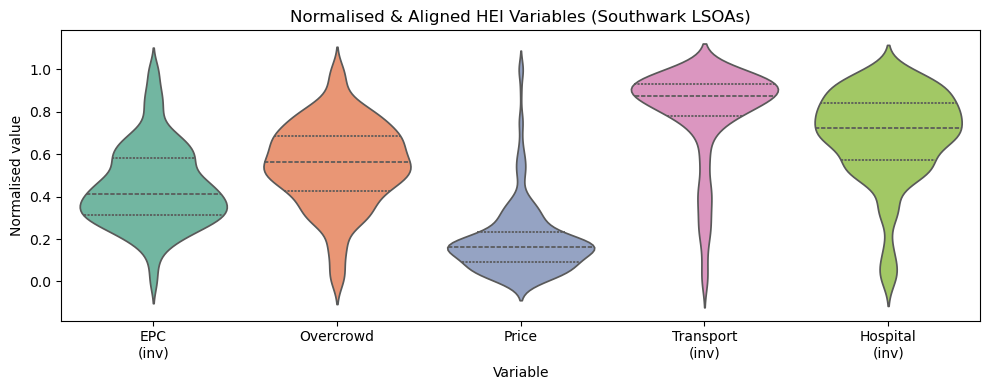

In [83]:
# --- 7.6  Normalisation check — violin plots ---
import seaborn as sns

plot_df = df[aligned_cols].melt(var_name='Variable', value_name='Normalised value')
plot_df['Variable'] = plot_df['Variable'].str.replace('_al', '', regex=False)

fig, ax = plt.subplots(figsize=(10, 4))
sns.violinplot(data=plot_df, x='Variable', y='Normalised value',
               palette='Set2', inner='quartile', ax=ax)
ax.set_title('Normalised & Aligned HEI Variables (Southwark LSOAs)')
ax.set_xticklabels(['EPC\n(inv)','Overcrowd','Price','Transport\n(inv)','Hospital\n(inv)'])
plt.tight_layout()
plt.show()

---
## 8. HEI Construction — Bayesian Latent Factor Index

**Primary method: Bayesian Latent Factor Analysis (K=1, Gibbs Sampling)**

> Model: `xᵢ = λ · fᵢ + εᵢ`  
> - `fᵢ ~ N(0, 1)` — latent housing equity score for LSOA *i*  
> - `λⱼ ~ N(0, 1)` with post-hoc sign correction — factor loadings  
> - `εᵢⱼ ~ N(0, ψⱼ)`,  `ψⱼ ~ InvGamma(1, 0.5)` — indicator noise  
>  
> All full conditionals are conjugate → exact Gibbs sampler (pure NumPy).  
> **Output**: posterior mean `fᵢ` → `HEI_bayes`; posterior SD → `HEI_bayes_uncert`; 95% HDI → `HEI_bayes_lo / hi`

KMO and Bartlett tests (Section 8.1) confirm multivariate structure.  
PCA (Section 8.2) is retained as a robustness comparator.

In [84]:
# --- 8.1  Suitability tests ---
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

X = df[aligned_cols].values

kmo_all, kmo_model = calculate_kmo(df[aligned_cols])
chi_sq, p_val      = calculate_bartlett_sphericity(df[aligned_cols])

print(f'KMO Measure of Sampling Adequacy : {kmo_model:.3f}  (>0.6 = acceptable)')
print(f"Bartlett's Test χ²               : {chi_sq:.2f},  p = {p_val:.4f}  (p<0.05 = significant)")

KMO Measure of Sampling Adequacy : 0.578  (>0.6 = acceptable)
Bartlett's Test χ²               : 871.69,  p = 0.0000  (p<0.05 = significant)


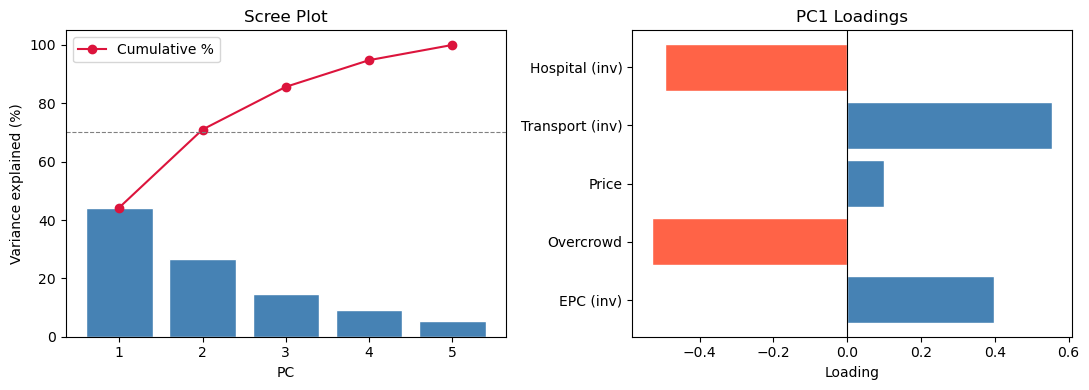

Explained variance per PC:
  PC1: 44.3%  (eigenvalue=0.089)
  PC2: 26.7%  (eigenvalue=0.054)
  PC3: 14.6%  (eigenvalue=0.029)
  PC4: 9.1%  (eigenvalue=0.018)
  PC5: 5.2%  (eigenvalue=0.010)


In [85]:
# --- 8.2  PCA ---
from sklearn.decomposition import PCA

n_vars = len(aligned_cols)
pca = PCA(n_components=n_vars)
pca.fit(X)

var_labels = ['EPC (inv)', 'Overcrowd', 'Price', 'Transport (inv)', 'Hospital (inv)']

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, n_vars+1), pca.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, n_vars+1),
             np.cumsum(pca.explained_variance_ratio_) * 100,
             'o-', color='crimson', label='Cumulative %')
axes[0].axhline(70, ls='--', color='grey', lw=0.8)
axes[0].set(title='Scree Plot', xlabel='PC', ylabel='Variance explained (%)')
axes[0].legend()

# PC1 loadings
loadings = pca.components_[0]
colors   = ['tomato' if l < 0 else 'steelblue' for l in loadings]
axes[1].barh(var_labels, loadings, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set(title='PC1 Loadings', xlabel='Loading')

plt.tight_layout()
plt.show()

print('Explained variance per PC:')
for i, ev in enumerate(pca.explained_variance_ratio_, 1):
    print(f'  PC{i}: {ev*100:.1f}%  (eigenvalue={pca.explained_variance_[i-1]:.3f})')

In [86]:
# --- 8.3  Bayesian Latent Factor Analysis — Gibbs Sampler (K=1) ---
#
# Full conditionals (all conjugate):
#
#  f_i | rest ~ N( sig2_f · Σ_j λ_j x_ij/ψ_j ,  sig2_f )
#    sig2_f = 1 / (1 + Σ_j λ_j²/ψ_j)
#
#  λ_j | rest ~ N( sig2_lam_j · (F'x_j)/ψ_j ,  sig2_lam_j )
#    sig2_lam_j = 1 / (1/τ² + F'F/ψ_j)
#
#  ψ_j | rest ~ InvGamma( a₀ + N/2 ,  b₀ + ½‖xⱼ − λⱼF‖² )

from scipy import stats as _stats

def bayesian_factor_gibbs(X, n_iter=3000, n_burn=1500, tau2=1.0,
                           a0=1.0, b0=0.5, seed=42, verbose=True):
    """
    Single-factor Bayesian Factor Analysis via Gibbs sampling.
    Sign ambiguity resolved post-hoc: flip so Σλ > 0.

    Parameters
    ----------
    X      : (N, J) normalised, direction-aligned indicator matrix
    n_iter : posterior iterations to keep
    n_burn : burn-in iterations (discarded)
    tau2   : Normal prior variance on loadings
    a0,b0  : InvGamma hyperparameters for noise ψⱼ
    seed   : RNG seed

    Returns
    -------
    f_samples   : (n_iter, N) posterior draws of latent factor
    lam_samples : (n_iter, J) posterior draws of loadings
    """
    rng = np.random.default_rng(seed)
    N, J = X.shape

    # Initialise
    lam = np.ones(J)
    psi = np.ones(J)
    F   = np.zeros(N)

    f_samples   = np.zeros((n_iter, N))
    lam_samples = np.zeros((n_iter, J))

    for t in range(n_iter + n_burn):
        if verbose and t % 1000 == 0:
            print(f'  iter {t}/{n_iter + n_burn}', end='\r')

        # ── Sample F ─────────────────────────────────────────────────
        sig2_f = 1.0 / (1.0 + np.sum(lam**2 / psi))
        mu_f   = sig2_f * (X @ (lam / psi))         # (N,)
        F      = rng.normal(mu_f, np.sqrt(sig2_f))   # (N,)

        # ── Sample λ (vectorised) ────────────────────────────────────
        FF       = float(np.dot(F, F))
        sig2_lam = 1.0 / (1.0/tau2 + FF/psi)         # (J,)
        mu_lam   = sig2_lam * (X.T @ F) / psi         # (J,)
        lam      = rng.normal(mu_lam, np.sqrt(sig2_lam))

        # ── Sample ψ (InvGamma via 1/Gamma) ─────────────────────────
        resid = X - np.outer(F, lam)
        rss   = np.sum(resid**2, axis=0)               # (J,)
        psi   = 1.0 / rng.gamma(a0 + N/2.0, 1.0/(b0 + rss/2.0))

        if t >= n_burn:
            f_samples[t - n_burn]   = F
            lam_samples[t - n_burn] = lam

    print()

    # ── Sign correction: enforce Σ_j λ̄_j > 0 ────────────────────────
    lam_mean_sum = lam_samples.mean(axis=0).sum()
    if lam_mean_sum < 0:
        f_samples   = -f_samples
        lam_samples = -lam_samples

    return f_samples, lam_samples


# ── Run ──────────────────────────────────────────────────────────────────────
X_bl = df[aligned_cols].values   # (N, 5)
# Guard: replace any residual NaN/inf with column median
if not np.isfinite(X_bl).all():
    import warnings
    warnings.warn('X_bl contains NaN/inf before Gibbs sampler — applying column-median fill')
    for j in range(X_bl.shape[1]):
        col_vals = X_bl[:, j]
        bad = ~np.isfinite(col_vals)
        if bad.any():
            med = float(np.nanmedian(col_vals))
            X_bl[bad, j] = med if np.isfinite(med) else 0.5
print(f'Bayesian Latent Factor Analysis — N={X_bl.shape[0]} LSOAs, J={X_bl.shape[1]} indicators')
print(f'Sampler: 3,000 posterior + 1,500 burn-in iterations (pure NumPy Gibbs)')

f_samples, lam_samples = bayesian_factor_gibbs(X_bl, n_iter=3000, n_burn=1500, seed=42)

# ── Posterior summaries ──────────────────────────────────────────────────────
f_mean  = f_samples.mean(axis=0)              # (N,)
f_std   = f_samples.std(axis=0)               # (N,)
hdi_lo  = np.percentile(f_samples,  2.5, axis=0)
hdi_hi  = np.percentile(f_samples, 97.5, axis=0)

lam_mean = lam_samples.mean(axis=0)
lam_std  = lam_samples.std(axis=0)
lam_lo   = np.percentile(lam_samples,  2.5, axis=0)
lam_hi   = np.percentile(lam_samples, 97.5, axis=0)

print('\n  Posterior loadings (mean  [95% HDI]):')
var_labels_al = ['EPC (inv)', 'Overcrowd', 'Price', 'Transport (inv)', 'Hospital (inv)']
for vname, lm, ll, lh in zip(var_labels_al, lam_mean, lam_lo, lam_hi):
    print(f'  {vname:<22}: λ = {lm:.3f}  [{ll:.3f}, {lh:.3f}]')

# ── Rescale to [0, 1] (higher = worse equity) ────────────────────────────────
def _mm(v):
    return (v - v.min()) / (v.max() - v.min())

df['HEI_bayes']        = _mm(f_mean)
df['HEI_bayes_uncert'] = _mm(f_std)
df['HEI_bayes_lo']     = _mm(hdi_lo)
df['HEI_bayes_hi']     = _mm(hdi_hi)

print('\nHEI_bayes summary (0=best equity, 1=worst equity):')
df['HEI_bayes'].describe().round(3)

Bayesian Latent Factor Analysis — N=708 LSOAs, J=5 indicators
Sampler: 3,000 posterior + 1,500 burn-in iterations (pure NumPy Gibbs)
  iter 4000/4500

  Posterior loadings (mean  [95% HDI]):
  EPC (inv)             : λ = 0.438  [0.412, 0.466]
  Overcrowd             : λ = 0.545  [0.514, 0.577]
  Price                 : λ = 0.191  [0.176, 0.208]
  Transport (inv)       : λ = 0.772  [0.729, 0.815]
  Hospital (inv)        : λ = 0.696  [0.661, 0.735]

HEI_bayes summary (0=best equity, 1=worst equity):


count   708.0000
mean      0.5530
std       0.1760
min       0.0000
25%       0.4580
50%       0.5710
75%       0.6780
max       1.0000
Name: HEI_bayes, dtype: float64

HEI_bayes quintile distribution:
HEI_quintile
Q1 (best)     142
Q2            141
Q3            142
Q4            141
Q5 (worst)    142
Name: count, dtype: int64

R̂ (split-chain convergence): mean=0.9998,  max=1.0014  (<1.05 = converged)


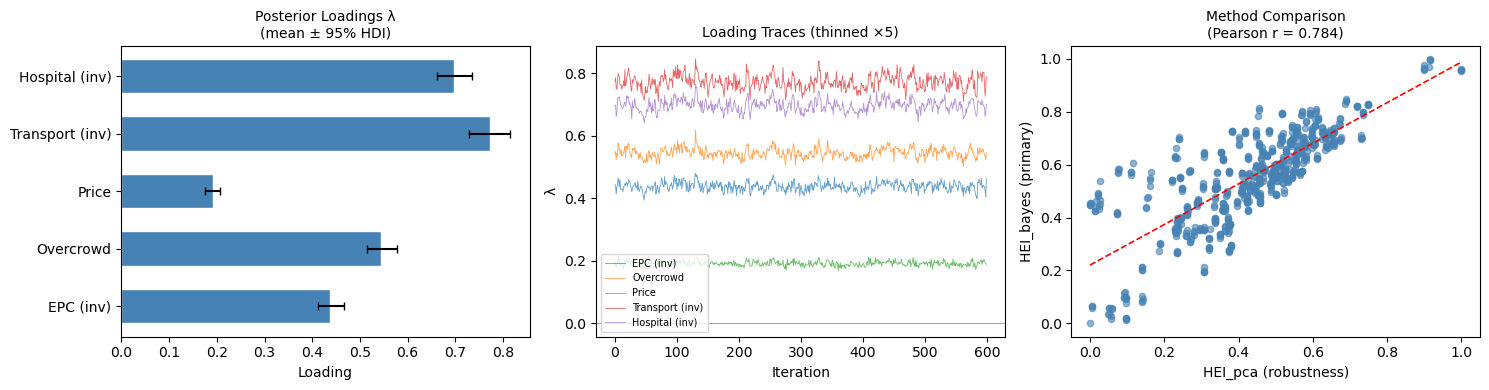


Correlations with HEI_bayes:  HEI_pca=0.784,  HEI_equal=0.877


In [87]:
# --- 8.4  PCA-weighted HEI (robustness reference) + Convergence Diagnostics ---

# Equal-weighted baseline
df['HEI_equal'] = _mm(df[aligned_cols].mean(axis=1).values)

# PCA-weighted (squared PC1 loading weights)
from sklearn.decomposition import PCA as _PCA
_pca    = _PCA(n_components=1).fit(X_bl)
pc1_sq  = _pca.components_[0] ** 2
weights = pc1_sq / pc1_sq.sum()
df['HEI_pca'] = _mm((X_bl * weights).sum(axis=1))

# Quintile classification (Bayesian HEI as primary)
df['HEI_quintile'] = pd.qcut(df['HEI_bayes'], q=5,
                               labels=['Q1 (best)', 'Q2', 'Q3', 'Q4', 'Q5 (worst)'])

print('HEI_bayes quintile distribution:')
print(df['HEI_quintile'].value_counts().sort_index())

# ── Split-chain R̂ (convergence diagnostic) ──────────────────────────────────
half   = f_samples.shape[0] // 2
c1, c2 = f_samples[:half], f_samples[half:]
W      = (c1.var(0) + c2.var(0)) / 2.0
B      = (half / 2.0) * ((c1.mean(0) - f_mean)**2 + (c2.mean(0) - f_mean)**2)
var_hat = ((half - 1) / half) * W + B / half
rhat   = np.sqrt(np.where(W > 0, var_hat / W, 1.0))
print(f'\nR̂ (split-chain convergence): mean={rhat.mean():.4f},  max={rhat.max():.4f}  (<1.05 = converged)')

# ── Figure: loadings + traces + method comparison ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Posterior loading distributions
axes[0].barh(var_labels_al, lam_mean,
             xerr=np.stack([lam_mean - lam_lo, lam_hi - lam_mean]),
             color='steelblue', edgecolor='white', capsize=3, height=0.6)
axes[0].axvline(0, color='grey', lw=0.8, ls='--')
axes[0].set_title('Posterior Loadings λ\n(mean ± 95% HDI)', fontsize=10)
axes[0].set_xlabel('Loading')

# (b) Loading trace (thinned)
thin = 5
colors_tr = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
for j, (vname, col) in enumerate(zip(var_labels_al, colors_tr)):
    axes[1].plot(lam_samples[::thin, j], alpha=0.7, lw=0.6, color=col, label=vname)
axes[1].set_title('Loading Traces (thinned ×5)', fontsize=10)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('λ')
axes[1].legend(fontsize=7); axes[1].axhline(0, color='grey', lw=0.5)

# (c) Method comparison scatter
corr_bp = np.corrcoef(df['HEI_bayes'], df['HEI_pca'])[0, 1]
axes[2].scatter(df['HEI_pca'], df['HEI_bayes'], s=20, alpha=0.6, color='steelblue')
m, b_coef = np.polyfit(df['HEI_pca'], df['HEI_bayes'], 1)
xs = np.linspace(0, 1, 50)
axes[2].plot(xs, m*xs + b_coef, 'r--', lw=1.2)
axes[2].set_xlabel('HEI_pca (robustness)'); axes[2].set_ylabel('HEI_bayes (primary)')
axes[2].set_title(f'Method Comparison\n(Pearson r = {corr_bp:.3f})', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'bayes_hei_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\nCorrelations with HEI_bayes:  HEI_pca={corr_bp:.3f},  HEI_equal={np.corrcoef(df["HEI_bayes"], df["HEI_equal"])[0,1]:.3f}')

  Shapefile: 173 polygons | df unique lsoa11cd: 166
  HEI_bayes: 19 unmatched polygons → filled with median 0.5633
  HEI_bayes_uncert: 19 unmatched polygons → filled with median 0.4147
  HEI_pca: 19 unmatched polygons → filled with median 0.4563
  HEI_equal: 19 unmatched polygons → filled with median 0.4450
  geo_hei NaN check: 0 remaining


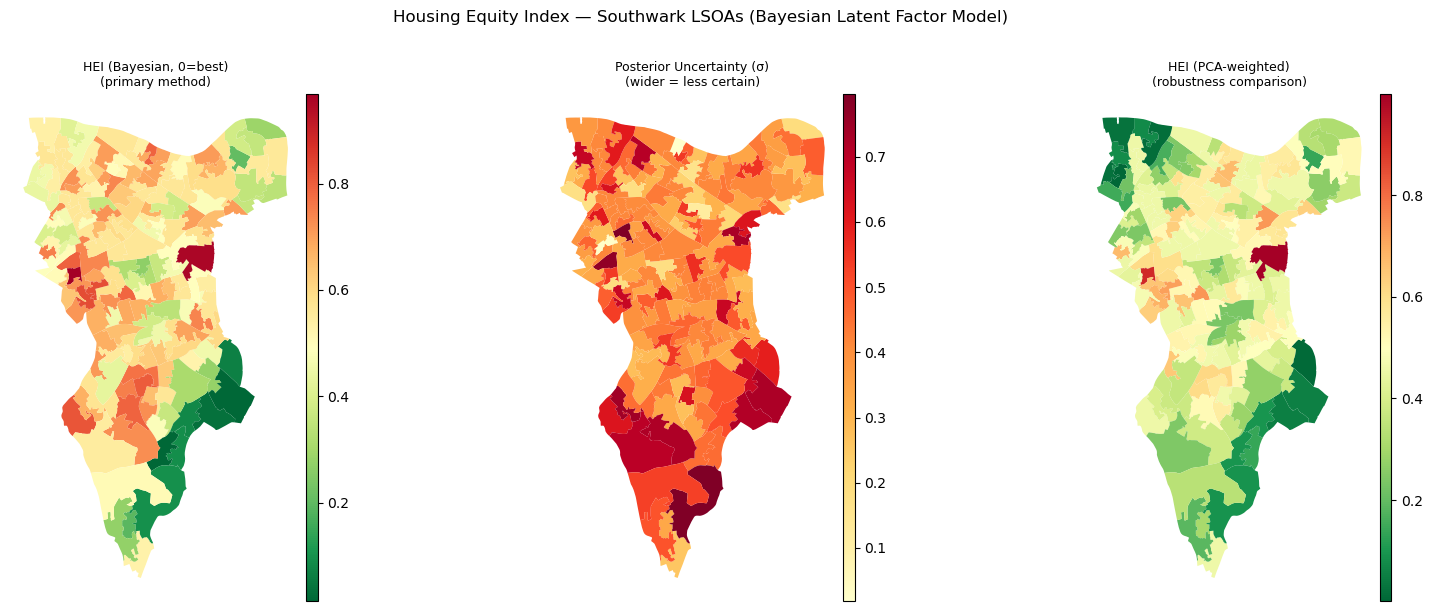

In [88]:
# --- 8.5  Spatial maps: HEI_bayes + uncertainty --------------------------------
import geopandas as gpd, glob, matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable

SHP_DIR   = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'LSOA_Shapfile')
shp_files = glob.glob(os.path.join(SHP_DIR, '*.shp'))
lsoa_gdf  = gpd.read_file(shp_files[0]).to_crs(epsg=27700)

geo_code_col = [c for c in lsoa_gdf.columns if 'cd' in c.lower() or 'code' in c.lower()][0]
southwark_lsoa11 = set(master['lsoa11cd'])
southwark_lsoa21 = set(master['lsoa21cd'])
geo_swk = lsoa_gdf[lsoa_gdf[geo_code_col].isin(southwark_lsoa11 | southwark_lsoa21)].copy()

join_key = 'lsoa11cd' if geo_swk[geo_code_col].isin(master['lsoa11cd']).mean() > 0.5 else 'lsoa21cd'

# Deduplicate df on the join key: master can have multiple rows per LSOA
# (from lsoa11cd→lsoa21cd boundary expansion); keep first occurrence
_hei_merge_cols = ['lsoa11cd', 'lsoa21cd', 'HEI_bayes', 'HEI_bayes_uncert',
                   'HEI_pca', 'HEI_equal', 'HEI_quintile']
_df_dedup = df[_hei_merge_cols].drop_duplicates(subset=[join_key], keep='first')
print(f'  Shapefile: {len(geo_swk)} polygons | df unique {join_key}: {_df_dedup[join_key].nunique()}')

geo_hei = geo_swk.merge(_df_dedup,
                        left_on=geo_code_col, right_on=join_key, how='left')

# Fill any unmatched polygons (LSOAs with no EPC records) with column median
_hei_num = ['HEI_bayes', 'HEI_bayes_uncert', 'HEI_pca', 'HEI_equal']
for _col in _hei_num:
    _n_nan = geo_hei[_col].isnull().sum()
    if _n_nan:
        _med = geo_hei[_col].median()
        geo_hei[_col] = geo_hei[_col].fillna(_med)
        print(f'  {_col}: {_n_nan} unmatched polygons → filled with median {_med:.4f}')
if geo_hei['HEI_quintile'].isnull().any():
    geo_hei['HEI_quintile'] = geo_hei['HEI_quintile'].fillna(
        geo_hei['HEI_quintile'].mode()[0])

print(f'  geo_hei NaN check: {geo_hei[_hei_num].isnull().sum().sum()} remaining')

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

panels = [
    ('HEI_bayes',        'RdYlGn_r', 'HEI (Bayesian, 0=best)',      'primary method'),
    ('HEI_bayes_uncert', 'YlOrRd',   'Posterior Uncertainty (σ)',    'wider = less certain'),
    ('HEI_pca',          'RdYlGn_r', 'HEI (PCA-weighted)',           'robustness comparison'),
]

for ax, (col, cmap, label, sub) in zip(axes, panels):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    geo_hei.plot(column=col, cmap=cmap, legend=True, ax=ax, cax=cax,
                 missing_kwds={'color': 'lightgrey'})
    ax.set_title(f'{label}\n({sub})', fontsize=9)
    ax.axis('off')

fig.suptitle('Housing Equity Index — Southwark LSOAs (Bayesian Latent Factor Model)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'map_HEI_bayes_southwark.png'), dpi=150, bbox_inches='tight')
plt.show()

In [89]:
# --- 8.6  Top / bottom 5 LSOAs by HEI_bayes ---
display_cols = ['lsoa21nm'] + aligned_cols + ['HEI_bayes', 'HEI_bayes_uncert', 'HEI_quintile']

print('=== Top 5 most deprived LSOAs (HEI_bayes highest) ===')
print(df.nlargest(5,  'HEI_bayes')[display_cols].round(3).to_string(index=False))

print('\n=== Top 5 best equity LSOAs (HEI_bayes lowest) ===')
print(df.nsmallest(5, 'HEI_bayes')[display_cols].round(3).to_string(index=False))

=== Top 5 most deprived LSOAs (HEI_bayes highest) ===
      lsoa21nm  avg_epc_rating_num_al  overcrowding_proxy_al  median_house_price_al  transport_ptai_al  hospital_al  HEI_bayes  HEI_bayes_uncert HEI_quintile
Southwark 021E                 0.6250                 0.9650                 0.1640             0.8040       0.9300     1.0000            0.5130   Q5 (worst)
Southwark 021E                 0.6250                 0.9650                 0.1640             0.8040       0.9300     0.9970            0.3160   Q5 (worst)
Southwark 021E                 0.6250                 0.9650                 0.1640             0.8040       0.9300     0.9950            0.5000   Q5 (worst)
Southwark 004I                 0.3810                 0.8550                 0.2070             0.9490       1.0000     0.9750            0.5360   Q5 (worst)
Southwark 021E                 0.6250                 0.9650                 0.0440             0.8040       0.9300     0.9680            0.5410   Q5 (worst

---
## 9. Save Final Dataset

In [90]:
# Merge HEI back to master (includes Bayesian + PCA + equal-weighted)
hei_cols = ['lsoa11cd'] + aligned_cols + [
    'HEI_bayes', 'HEI_bayes_uncert', 'HEI_bayes_lo', 'HEI_bayes_hi',
    'HEI_equal', 'HEI_pca', 'HEI_quintile'
]
master_final = master.merge(df[hei_cols], on='lsoa11cd', how='left')

# ── Post-merge NaN fill (handles any lsoa11cd join mismatches) ─────────────
_hei_num_cols = ['HEI_bayes', 'HEI_bayes_uncert', 'HEI_bayes_lo', 'HEI_bayes_hi',
                  'HEI_equal', 'HEI_pca'] + aligned_cols
for col in _hei_num_cols:
    if col in master_final.columns and master_final[col].isnull().any():
        _med = master_final[col].median()
        _n   = master_final[col].isnull().sum()
        master_final[col] = master_final[col].fillna(_med if pd.notna(_med) else 0.5)
        print(f'  Post-merge fill: {col}: {_n} NaN → median {_med:.4f}')

# HEI_quintile (categorical)
if 'HEI_quintile' in master_final.columns and master_final['HEI_quintile'].isnull().any():
    master_final['HEI_quintile'] = master_final['HEI_quintile'].fillna(
        master_final['HEI_quintile'].mode()[0])

# Final assertion
_null_hei = master_final[_hei_num_cols].isnull().sum()
assert _null_hei.sum() == 0, f'HEI NaN still present:\n{_null_hei[_null_hei>0]}'
print('✓ All HEI columns: zero missing values in master_final')

out_path = os.path.join(DATA_DIR, 'master_southwark_hei.csv')
master_final.to_csv(out_path, index=False)

print(f'Saved → {out_path}')
print(f'Shape : {master_final.shape}')
print('\nHEI columns saved:', [c for c in master_final.columns if 'HEI' in c or '_al' in c])

✓ All HEI columns: zero missing values in master_final
Saved → /Users/kevin/Desktop/代写/lxy/code/data/master_southwark_hei.csv
Shape : (3216, 35)

HEI columns saved: ['avg_epc_rating_num_al', 'overcrowding_proxy_al', 'median_house_price_al', 'transport_ptai_al', 'hospital_al', 'HEI_bayes', 'HEI_bayes_uncert', 'HEI_bayes_lo', 'HEI_bayes_hi', 'HEI_equal', 'HEI_pca', 'HEI_quintile']
